# Notebook 5c
Through training RGB-derived models for identifying clouds using TSIs as training data, it is apparent brightness temperature is a major factor. The brightness temperature thresholds scale with respect to mean daily air temperatures, as shown in Notebook 5b. Here, we will pull in PRISM air temperature data to modify the brightness temperature thresholds dynamically. This should resolve issues identifying low, relatively warm clouds (like 2 January 2023 east of the Front Range of Colorado).

In [1]:
import xarray as xr
import cfgrib
import numpy as np
import matplotlib.pyplot as plt
import os
import imageio
import pandas as pd



In [2]:
# import cdsapi

# c = cdsapi.Client()

# c.retrieve(
#     'reanalysis-era5-land',
#     {
#         'variable': '2m_temperature',
#         'year': ['2023'],
#         'month': [f'{m:02d}' for m in range(1, 3)],
#         'day': [f'{d:02d}' for d in range(1, 32)],
#         'time': [f'{h:02d}:00' for h in range(0, 24)],
#         'area': [41, -109, 37, -104],  # North, West, South, East
#         'data_format': 'netcdf',
#     },
#     'era5land_surface_temp_2023.nc'
# )


In [3]:
# import zipfile

# zip_path = "era5land_surface_temp_2023.nc"

# with zipfile.ZipFile(zip_path, 'r') as z:
#     z.extractall()


# z.namelist()


In [2]:
date = '20230102'

path = '/home/cdalden/goes_work/analysis/era5land_surface_temp_2023.nc'
era5_ds = xr.open_dataset(path, engine='netcdf4')
era5_ds['t2m'] = era5_ds['t2m'] - 273.15  # Convert from Kelvin to Celsius
era5_ds = era5_ds.sel(valid_time=f'{date}')

file = f'goes16_C02_C05_C13_rgb_colorado_{date}.nc'
rgb = xr.open_dataset('/storage/cdalden/goes/colorado/goes16/rgb_composite/' + file)

acm_path = '/storage/cdalden/goes/colorado/goes16/cloud_counts/'
acm_file = f'goes_acm_colorado_{date}.nc'
try:
    acm_ds = xr.open_dataset(acm_path + acm_file)
    acm_ds
except FileNotFoundError:
    print(f"File {acm_file} not found in {acm_path}.")


/home/cdalden/miniforge3/envs/goes_env/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
era5_ds

<xarray.Dataset> Size: 202kB
Dimensions:     (valid_time: 24, latitude: 41, longitude: 51)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2023-01-02 ... 2023-01-02T23...
  * latitude    (latitude) float64 328B 41.0 40.9 40.8 40.7 ... 37.2 37.1 37.0
  * longitude   (longitude) float64 408B -109.0 -108.9 -108.8 ... -104.1 -104.0
    number      int64 8B ...
    expver      (valid_time) <U4 384B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 201kB -1.976 ... -0...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-10T20:01 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
acm_ds['ACM'] = xr.where((acm_ds['ACM'] == 3) | (acm_ds['ACM'] == 4), 1, 0)

In [6]:
# helper: build extent and crop ds
def get_extent_and_ds(ds, domain='east_river'):
    lon = ds['longitude'].values
    lat = ds['latitude'].values
    if domain == 'east_river':
        lon_min, lon_max = -107.75, -105.75
        lat_min, lat_max = 38.3, 39.4
        ds_sub = ds.where(
            (ds['longitude'] >= lon_min) & (ds['longitude'] <= lon_max) &
            (ds['latitude'] >= lat_min) & (ds['latitude'] <= lat_max),
            drop=True
        )
        extent = [lon_min, lon_max, lat_min, lat_max]
    else:
        ds_sub = ds
        extent = [lon.min(), lon.max(), lat.min(), lat.max()]
    return ds_sub, extent

In [ ]:
# Settings
start_hour = 15
end_hour = 20
out_dir = './gifs'
os.makedirs(out_dir, exist_ok=True)
out_gif = os.path.join(out_dir, f'4panel_{date}_{start_hour:02d}-{end_hour:02d}.gif')
fps = 8
domain = None   # or None

# temp bins / thresholds from earlier
temp_bins = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
red_thresholds = [0.40, 0.40, 0.38, 0.36, 0.23, 0.22, 0.10, 0.10]

# choose RGB times in window
rgb_times = [t for t in rgb.t.values if start_hour <= pd.to_datetime(t).hour <= end_hour]
print(f'Will render {len(rgb_times)} frames')



# GIF writer
with imageio.get_writer(out_gif, mode='I', fps=fps) as writer:
    for i, tval in enumerate(rgb_times):
        # select RGB snapshot
        rgb_snap = rgb.sel(t=tval, method='nearest')

        # find nearest ERA5 time and interpolate to RGB grid
        # adapt valid_time/time key as in your ERA5 dataset
        era5_snap = era5_ds.sel(valid_time=rgb_snap.t.values, method='nearest')
        era5_interp = era5_snap.interp(latitude=rgb_snap.latitude,
                                       longitude=rgb_snap.longitude,
                                       method='linear')

        # red threshold array per-pixel from ERA5 t2m
        red_threshold_array = xr.full_like(era5_interp['t2m'], np.nan)
        for j in range(len(temp_bins) - 1):
            temp_mask = (era5_interp['t2m'] >= temp_bins[j]) & (era5_interp['t2m'] < temp_bins[j+1])
            red_threshold_array = xr.where(temp_mask, red_thresholds[j], red_threshold_array)

        # Masks
        cloud_mask = (rgb_snap['red'] > red_threshold_array) & (rgb_snap['blue'] > 0.13)
        winter_mask = (rgb_snap['red'] > 0.39) & (rgb_snap['blue'] > 0.13)
        diff = cloud_mask.astype(int) - winter_mask.astype(int)

        # Prepare RGB image (crop/resample to smallest common shape)
        ds_for_rgb = rgb_snap  # xarray DataArray dataset containing red,green,blue
        ds_crop, extent = get_extent_and_ds(ds_for_rgb, domain=domain)

        red = ds_crop['red'].values
        green = ds_crop['green'].values
        blue = ds_crop['blue'].values
        # if arrays have extra dims (time), squeeze them
        if red.ndim == 3: red = np.squeeze(red)
        if green.ndim == 3: green = np.squeeze(green)
        if blue.ndim == 3: blue = np.squeeze(blue)

        # ensure shape agreement and stack to RGB
        min_shape = np.min([red.shape, green.shape, blue.shape], axis=0)
        red_resized = red[:min_shape[0], :min_shape[1]]
        green_resized = green[:min_shape[0], :min_shape[1]]
        blue_resized = blue[:min_shape[0], :min_shape[1]]
        rgb_image = np.stack([red_resized, green_resized, blue_resized], axis=-1)

        # Crop masks to same extent/shape
        def crop_da_to_shape(da, target_shape):
            arr = da.values
            if arr.ndim == 3: arr = np.squeeze(arr)
            return arr[:target_shape[0], :target_shape[1]]

        # target_shape already computed from RGB
        target_shape = red_resized.shape

        # convert booleans → ints so interp accepts them, use nearest, then convert/slice
        cloud_sel = cloud_mask.astype(int).interp(
            latitude=ds_crop.latitude, longitude=ds_crop.longitude, method='nearest'
        )
        winter_sel = winter_mask.astype(int).interp(
            latitude=ds_crop.latitude, longitude=ds_crop.longitude, method='nearest'
        )

        def crop_da_to_shape_from_arr(arr_da, target_shape):
            arr = arr_da.values
            if arr.ndim == 3:
                arr = np.squeeze(arr)
            return arr[:target_shape[0], :target_shape[1]]

        cloud_arr = crop_da_to_shape_from_arr(cloud_sel, target_shape).astype(int)
        winter_arr = crop_da_to_shape_from_arr(winter_sel, target_shape).astype(int)
        diff_arr = cloud_arr - winter_arr

        acm_snap = acm_ds.sel(t=rgb_snap.t.values, method='nearest')
        acm_crop, _ = get_extent_and_ds(acm_snap, domain=domain)
        acm_array = acm_crop['ACM'].squeeze().values
        if acm_array.ndim == 3:
            acm_array = np.squeeze(acm_array)
        acm_arr = acm_array[:target_shape[0], :target_shape[1]]

        # Create figure 2x2
        fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

        # 1) RGB
        ax = axes[0,0]
        ax.imshow(rgb_image, extent=extent, origin='upper')
        ax.set_title('GOES RGB\n' + pd.to_datetime(tval).strftime('%Y-%m-%d %H:%M UTC'))
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

        # 2) cloud_mask
        ax = axes[0,1]
        im1 = ax.imshow(cloud_arr, extent=extent, cmap='Blues', vmin=0, vmax=1, origin='upper')
        ax.set_title('Temperature-Dependent Cloud Mask')
        plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

        # 3) winter_mask
        ax = axes[1,0]
        im2 = ax.imshow(winter_arr, extent=extent, cmap='Blues', vmin=0, vmax=1, origin='upper')
        ax.set_title('Fixed Mask')
        plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

        # 4) diff
        ax = axes[1,1]
        im3 = ax.imshow(diff_arr, extent=extent, cmap='RdBu', vmin=-1, vmax=1, origin='upper')
        ax.set_title('Difference (Temp-adj minus Fixed thresholds)')
        plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

        # 5) ACM column
        ax = axes[1,2]
        im4 = ax.imshow(acm_arr, extent=extent, cmap='Blues', vmin=0, vmax=1, origin='upper')
        ax.set_title('GOES Clear Sky Mask (ACM)')
        plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)

        # Save frame and append to GIF
        tmpfile = os.path.join(out_dir, f'frame_{i:04d}.png')
        fig.savefig(tmpfile, dpi=150, bbox_inches='tight')
        plt.close(fig)

        writer.append_data(imageio.v2.imread(tmpfile))
        os.remove(tmpfile)

        if (i + 1) % 10 == 0 or (i + 1) == len(rgb_times):
            print(f'Appended frame {i+1}/{len(rgb_times)}')

print('Saved GIF to', out_gif)

Will render 72 frames
Appended frame 10/72
Appended frame 20/72
Appended frame 30/72
Appended frame 40/72
Appended frame 50/72
Appended frame 60/72
Appended frame 70/72
Appended frame 72/72
Saved GIF to ./gifs/4panel_20230201_15-20.gif


In [10]:
# Settings
start_hour = 15
end_hour = 20
out_dir = './gifs'
os.makedirs(out_dir, exist_ok=True)
out_gif = os.path.join(out_dir, f'rgb_rgbmask_acm_{date}_{start_hour:02d}-{end_hour:02d}.gif')
fps = 8
domain = None   # or None

# temp bins / thresholds from earlier
temp_bins = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
red_thresholds = [0.40, 0.40, 0.38, 0.36, 0.23, 0.22, 0.10, 0.10]

# choose RGB times in window
rgb_times = [t for t in rgb.t.values if start_hour <= pd.to_datetime(t).hour <= end_hour]
print(f'Will render {len(rgb_times)} frames')



# GIF writer
with imageio.get_writer(out_gif, mode='I', fps=fps) as writer:
    for i, tval in enumerate(rgb_times):
        # select RGB snapshot
        rgb_snap = rgb.sel(t=tval, method='nearest')

        # find nearest ERA5 time and interpolate to RGB grid
        # adapt valid_time/time key as in your ERA5 dataset
        era5_snap = era5_ds.sel(valid_time=rgb_snap.t.values, method='nearest')
        era5_interp = era5_snap.interp(latitude=rgb_snap.latitude,
                                       longitude=rgb_snap.longitude,
                                       method='linear')

        # red threshold array per-pixel from ERA5 t2m
        red_threshold_array = xr.full_like(era5_interp['t2m'], np.nan)
        for j in range(len(temp_bins) - 1):
            temp_mask = (era5_interp['t2m'] >= temp_bins[j]) & (era5_interp['t2m'] < temp_bins[j+1])
            red_threshold_array = xr.where(temp_mask, red_thresholds[j], red_threshold_array)

        # Masks
        cloud_mask = (rgb_snap['red'] > red_threshold_array) & (rgb_snap['blue'] > 0.13)
        winter_mask = (rgb_snap['red'] > 0.39) & (rgb_snap['blue'] > 0.13)
        diff = cloud_mask.astype(int) - winter_mask.astype(int)

        # Prepare RGB image (crop/resample to smallest common shape)
        ds_for_rgb = rgb_snap  # xarray DataArray dataset containing red,green,blue
        ds_crop, extent = get_extent_and_ds(ds_for_rgb, domain=domain)

        red = ds_crop['red'].values
        green = ds_crop['green'].values
        blue = ds_crop['blue'].values
        # if arrays have extra dims (time), squeeze them
        if red.ndim == 3: red = np.squeeze(red)
        if green.ndim == 3: green = np.squeeze(green)
        if blue.ndim == 3: blue = np.squeeze(blue)

        # ensure shape agreement and stack to RGB
        min_shape = np.min([red.shape, green.shape, blue.shape], axis=0)
        red_resized = red[:min_shape[0], :min_shape[1]]
        green_resized = green[:min_shape[0], :min_shape[1]]
        blue_resized = blue[:min_shape[0], :min_shape[1]]
        rgb_image = np.stack([red_resized, green_resized, blue_resized], axis=-1)

        # Crop masks to same extent/shape
        def crop_da_to_shape(da, target_shape):
            arr = da.values
            if arr.ndim == 3: arr = np.squeeze(arr)
            return arr[:target_shape[0], :target_shape[1]]

        # target_shape already computed from RGB
        target_shape = red_resized.shape

        # convert booleans → ints so interp accepts them, use nearest, then convert/slice
        cloud_sel = cloud_mask.astype(int).interp(
            latitude=ds_crop.latitude, longitude=ds_crop.longitude, method='nearest'
        )
        winter_sel = winter_mask.astype(int).interp(
            latitude=ds_crop.latitude, longitude=ds_crop.longitude, method='nearest'
        )

        def crop_da_to_shape_from_arr(arr_da, target_shape):
            arr = arr_da.values
            if arr.ndim == 3:
                arr = np.squeeze(arr)
            return arr[:target_shape[0], :target_shape[1]]

        cloud_arr = crop_da_to_shape_from_arr(cloud_sel, target_shape).astype(int)
        winter_arr = crop_da_to_shape_from_arr(winter_sel, target_shape).astype(int)
        diff_arr = cloud_arr - winter_arr

        acm_snap = acm_ds.sel(t=rgb_snap.t.values, method='nearest')
        acm_crop, _ = get_extent_and_ds(acm_snap, domain=domain)
        acm_array = acm_crop['ACM'].squeeze().values
        if acm_array.ndim == 3:
            acm_array = np.squeeze(acm_array)
        acm_arr = acm_array[:target_shape[0], :target_shape[1]]

        # Create figure 2x2
        fig, axes = plt.subplots(1, 3, figsize=(18, 10), constrained_layout=True)

        # 1) RGB
        ax = axes[0]
        ax.imshow(rgb_image, extent=extent, origin='upper')
        ax.set_title('GOES RGB\n' + pd.to_datetime(tval).strftime('%Y-%m-%d %H:%M UTC'))
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

        # 3) winter_mask
        ax = axes[1]
        im2 = ax.imshow(winter_arr, extent=extent, cmap='Blues', vmin=0, vmax=1, origin='upper')
        ax.set_title('RGB-derived Cloud Mask')
        plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

        # 5) ACM column
        ax = axes[2]
        im4 = ax.imshow(acm_arr, extent=extent, cmap='Blues', vmin=0, vmax=1, origin='upper')
        ax.set_title('GOES Clear Sky Mask (ACM)')
        plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)

        # Save frame and append to GIF
        tmpfile = os.path.join(out_dir, f'frame_{i:04d}.png')
        fig.savefig(tmpfile, dpi=150, bbox_inches='tight')
        plt.close(fig)

        writer.append_data(imageio.v2.imread(tmpfile))
        os.remove(tmpfile)

        if (i + 1) % 10 == 0 or (i + 1) == len(rgb_times):
            print(f'Appended frame {i+1}/{len(rgb_times)}')

print('Saved GIF to', out_gif)

Will render 72 frames
Appended frame 10/72
Appended frame 20/72
Appended frame 30/72
Appended frame 40/72
Appended frame 50/72
Appended frame 60/72
Appended frame 70/72
Appended frame 72/72
Saved GIF to ./gifs/rgb_rgbmask_acm_20230102_15-20.gif


In [18]:
# Check the red threshold array
print("Red threshold array stats:")
print(f"Min: {red_threshold_array.min().values}")
print(f"Max: {red_threshold_array.max().values}")
print(f"Mean: {red_threshold_array.mean().values}")
print(f"Unique values: {np.unique(red_threshold_array.values)}")

print("\nTemperature stats:")
print(f"Min: {era5_interp['t2m'].min().values}")
print(f"Max: {era5_interp['t2m'].max().values}")
print(f"Mean: {era5_interp['t2m'].mean().values}")

print("\nRGB red channel stats:")
print(f"Min: {rgb_1800['red'].min().values}")
print(f"Max: {rgb_1800['red'].max().values}")
print(f"Mean: {rgb_1800['red'].mean().values}")

print("\nRGB green channel stats:")
print(f"Min: {rgb_1800['green'].min().values}")
print(f"Max: {rgb_1800['green'].max().values}")
print(f"Mean: {rgb_1800['green'].mean().values}")

# Check how many pass each condition
print(f"\nPixels where green > 0.19: {(rgb_1800['green'] > 0.19).sum().values}")
print(f"Pixels where red > threshold: {(rgb_1800['red'] > red_threshold_array).sum().values}")
print(f"Pixels where both conditions met: {cloud_mask.sum().values}")

Red threshold array stats:
Min: 0.22
Max: 0.38
Mean: 0.347793313710704
Unique values: [0.22 0.23 0.36 0.38  nan]

Temperature stats:
Min: -9.818726791941872
Max: 5.14128323012783
Mean: -3.0084666895935883

RGB red channel stats:
Min: 0.060583996381915695
Max: 0.9190554759541496
Mean: 0.5297408082761706

RGB green channel stats:
Min: 0.05529757961630821
Max: 0.9559595584869385
Mean: 0.39195355772972107

Pixels where green > 0.19: 600327
Pixels where red > threshold: 483744
Pixels where both conditions met: 471706


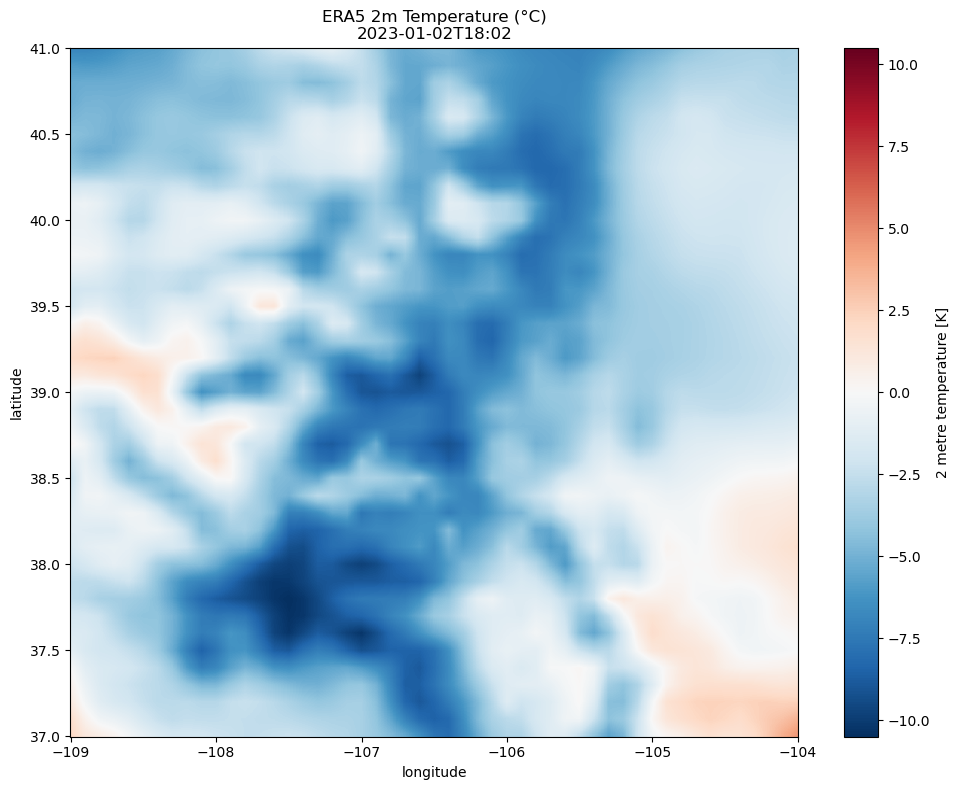

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
era5_interp['t2m'].plot(x='longitude', y='latitude', cmap='RdBu_r', ax=ax)
ax.set_title(f'ERA5 2m Temperature (°C)\n{str(rgb_1800.t.values)[:16]}')
plt.tight_layout()
plt.show()

## Plot random red, green, and blue scenes for paper workflow plot

In [15]:
rgb_timestep_ds = rgb.sel(t='2023-01-02 20:00', method='nearest')

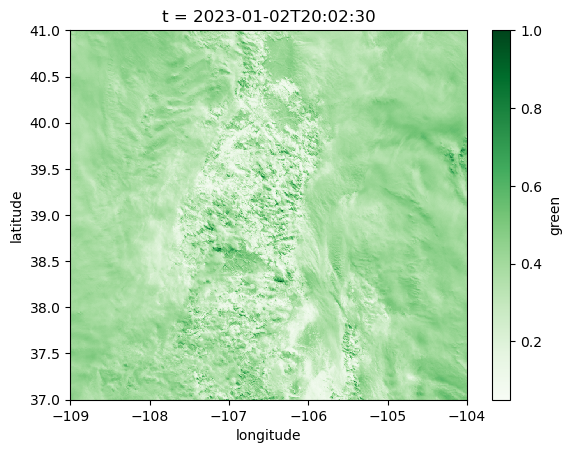

In [21]:
rgb_timestep_ds.green.plot(cmap='Greens')
